# Classification WITH Segmentation — 3 New Models

**Pipeline:** Raw image → LightUNet crop → Classify

Trains three classifiers on wound-cropped images (produced by the **LightUNet** segmentation model — Dice 0.8628).

| # | Model | Backbone | Params |
|---|-------|----------|--------|
| 1 | EfficientNet-B3 | EfficientNet-B3 | ~12M |
| 2 | ResNet-50 | ResNet-50 | ~25M |
| 3 | ConvNeXt-Tiny | ConvNeXt-Tiny | ~28M |

**Prerequisite:** Run `06_5_new_segmentation_deeplabv3.ipynb` first.

**Saves to:** `outputs/models/cls_withseg_*.pth`

## Cell 1: Imports & Configuration

In [2]:
import os, random, warnings, copy
warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms, datasets, models
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                             recall_score, roc_curve, auc, classification_report)
import seaborn as sns

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

BASE           = r'C:\Users\PC\Desktop\GraduationProject\MyProjectSTILL\FirstTry'
SEG_MODEL_PATH = os.path.join(BASE, 'outputs', 'models', 'segmentation_lightweight_unet.pth')
RAW_CLS        = os.path.join(BASE, 'TRAINTEST')
NEW_CROPPED    = os.path.join(BASE, 'outputs', 'new_cropped_data')
MODEL_DIR      = os.path.join(BASE, 'outputs', 'models')
VIZ_DIR        = os.path.join(BASE, 'outputs', 'visualizations')
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(VIZ_DIR, exist_ok=True)

DEVICE        = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
IMG_SIZE      = 224
BATCH_SIZE    = 32

# Three-phase training hyperparams (same strategy as V4)
P1_EP, P1_LR = 10, 5e-4
P2_EP, P2_LR = 15, 1e-4
P3_EP, P3_LR = 15, 1e-5
WEIGHT_DECAY  = 5e-4
PATIENCE      = 10
MIXUP_ALPHA   = 0.2

CLASS_NAMES   = ['infected', 'non-infected']

plt.rcParams.update({
    'figure.facecolor':'#0d1117', 'axes.facecolor':'#161b22',
    'axes.edgecolor':'#30363d',   'axes.labelcolor':'#c9d1d9',
    'text.color':'#c9d1d9',       'xtick.color':'#8b949e',
    'ytick.color':'#8b949e',      'grid.color':'#21262d', 'font.size':11
})
ACCENT, GREEN, BLUE, YELLOW, PURPLE = '#e94560','#3fb950','#58a6ff','#e3b341','#bc8cff'

print(f'Device : {DEVICE}')
if not os.path.exists(SEG_MODEL_PATH):
    print('WARNING: segmentation_lightweight_unet.pth not found. Run notebook 06_5 first!')
else:
    print(f'Segmentation model found  (LightUNet — Dice 0.8628)')
print('Imports OK')

Device : cpu
Segmentation model found  (LightUNet — Dice 0.8628)
Imports OK


## Cell 2: Load Segmentation Model

In [3]:
# ── Rebuild LightUNet architecture (must match 06_5 exactly) ─────────────
class ConvBlock(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_c), nn.ReLU(inplace=True),
            nn.Conv2d(out_c, out_c, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_c), nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.block(x)

class LightUNet(nn.Module):
    def __init__(self, in_ch=3, out_ch=1, base=32):
        super().__init__()
        b = base
        self.enc1       = ConvBlock(in_ch, b)
        self.enc2       = ConvBlock(b,     b*2)
        self.enc3       = ConvBlock(b*2,   b*4)
        self.enc4       = ConvBlock(b*4,   b*8)
        self.bottleneck = ConvBlock(b*8,   b*16)
        self.up4  = nn.ConvTranspose2d(b*16, b*8, 2, stride=2)
        self.dec4 = ConvBlock(b*16, b*8)
        self.up3  = nn.ConvTranspose2d(b*8,  b*4, 2, stride=2)
        self.dec3 = ConvBlock(b*8,  b*4)
        self.up2  = nn.ConvTranspose2d(b*4,  b*2, 2, stride=2)
        self.dec2 = ConvBlock(b*4,  b*2)
        self.up1  = nn.ConvTranspose2d(b*2,  b,   2, stride=2)
        self.dec1 = ConvBlock(b*2,  b)
        self.pool = nn.MaxPool2d(2)
        self.head = nn.Conv2d(b, out_ch, 1)
    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        bn = self.bottleneck(self.pool(e4))
        d4 = self.dec4(torch.cat([self.up4(bn), e4], dim=1))
        d3 = self.dec3(torch.cat([self.up3(d4), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return self.head(d1)  # (B, 1, H, W) logits — no dict wrapper

def load_seg_model(path):
    m  = LightUNet(in_ch=3, out_ch=1, base=32)
    ck = torch.load(path, map_location=DEVICE, weights_only=False)
    sd = ck['model_state_dict'] if 'model_state_dict' in ck else ck
    m.load_state_dict(sd)
    m.to(DEVICE).eval()
    return m

seg_model = load_seg_model(SEG_MODEL_PATH)
print(f'LightUNet loaded from {os.path.basename(SEG_MODEL_PATH)}')
print(f'  Val Dice saved in checkpoint: —')

# Input size matches 06_5 training (256×256, not 512×512)
SEG_TF = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

LightUNet loaded from segmentation_lightweight_unet.pth
  Val Dice saved in checkpoint: —


## Cell 3: Wound Crop Function

In [4]:
def crop_wound(img_pil, seg_model, threshold=0.5, padding=20):
    """
    Segment the wound and crop to its bounding box.
    Falls back to full image if no wound region is detected.
    """
    W, H = img_pil.size
    with torch.no_grad():
        inp  = SEG_TF(img_pil).unsqueeze(0).to(DEVICE)
        out  = seg_model(inp)
        mask = torch.sigmoid(out).squeeze().cpu().numpy()

    binary = (mask > threshold).astype(np.uint8)
    ys, xs = np.where(binary)

    if len(xs) == 0 or len(ys) == 0:
        return img_pil  # no wound found — keep original

    # Scale bounding box from 256px space back to original image size
    scale_x, scale_y = W / 256, H / 256
    x1 = max(0, int(xs.min() * scale_x) - padding)
    x2 = min(W, int(xs.max() * scale_x) + padding)
    y1 = max(0, int(ys.min() * scale_y) - padding)
    y2 = min(H, int(ys.max() * scale_y) + padding)

    if (x2 - x1) < 20 or (y2 - y1) < 20:
        return img_pil  # crop too small — keep original

    return img_pil.crop((x1, y1, x2, y2))

print('Crop function defined.')


Crop function defined.


## Cell 4: Generate Cropped Dataset

Runs segmentation on every TRAINTEST image and saves cropped crops.
**Skip if already done** (checks if folder exists).

In [5]:
IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff'}

def process_split(split_src, split_dst):
    os.makedirs(split_dst, exist_ok=True)
    class_dirs = [d for d in os.listdir(split_src)
                  if os.path.isdir(os.path.join(split_src, d))]
    total = 0
    for cls in class_dirs:
        src_cls = os.path.join(split_src, cls)
        dst_cls = os.path.join(split_dst, cls.lower())
        os.makedirs(dst_cls, exist_ok=True)
        files   = [f for f in os.listdir(src_cls)
                   if os.path.splitext(f)[1].lower() in IMG_EXTS]
        print(f'  {cls}: {len(files)} images -> {dst_cls}')
        for fname in files:
            dst_path = os.path.join(dst_cls, fname)
            if os.path.exists(dst_path):
                continue
            try:
                img     = Image.open(os.path.join(src_cls, fname)).convert('RGB')
                cropped = crop_wound(img, seg_model)
                cropped.save(dst_path)
                total += 1
            except Exception as e:
                print(f'    Error {fname}: {e}')
    return total

splits = [
    ('Train', os.path.join(RAW_CLS, 'Train'), os.path.join(NEW_CROPPED, 'train')),
    ('Valid', os.path.join(RAW_CLS, 'Valid'), os.path.join(NEW_CROPPED, 'valid')),
    ('test',  os.path.join(RAW_CLS, 'test'),  os.path.join(NEW_CROPPED, 'test')),
]

if os.path.exists(NEW_CROPPED) and os.listdir(NEW_CROPPED):
    print(f'Cropped dataset already exists at {NEW_CROPPED}')
    print('Delete it to regenerate.')
else:
    print('Generating cropped dataset (this may take a few minutes)...')
    for name, src, dst in splits:
        print(f'\n[{name}]')
        n = process_split(src, dst)
        print(f'  Saved {n} new images')
    print(f'\nDone. Cropped dataset at: {NEW_CROPPED}')

Cropped dataset already exists at C:\Users\PC\Desktop\GraduationProject\MyProjectSTILL\FirstTry\outputs\new_cropped_data
Delete it to regenerate.


## Cell 5: Data Loaders (Cropped Images)

In [6]:
train_tf = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomVerticalFlip(0.3),
    transforms.RandomRotation(25),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.25, hue=0.1),
    transforms.RandomAffine(degrees=10, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.15, scale=(0.02, 0.1)),
])
val_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

train_ds = datasets.ImageFolder(os.path.join(NEW_CROPPED, 'train'), transform=train_tf)
val_ds   = datasets.ImageFolder(os.path.join(NEW_CROPPED, 'valid'), transform=val_tf)
test_ds  = datasets.ImageFolder(os.path.join(NEW_CROPPED, 'test'),  transform=val_tf)

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, drop_last=True)
val_dl   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_dl  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f'Classes : {train_ds.classes}')
print(f'Train   : {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}')

Classes : ['infected', 'non-infected']
Train   : 700 | Val: 170 | Test: 152


## Cell 6: Model Architectures

In [7]:
def build_efficientnet_b3(num_classes=2):
    m  = models.efficientnet_b3(weights='DEFAULT')
    nf = m.classifier[1].in_features
    m.classifier = nn.Sequential(
        nn.Dropout(p=0.4),
        nn.Linear(nf, 512), nn.BatchNorm1d(512), nn.ReLU(inplace=True),
        nn.Dropout(p=0.3),
        nn.Linear(512, 128), nn.BatchNorm1d(128), nn.ReLU(inplace=True),
        nn.Dropout(p=0.2),
        nn.Linear(128, num_classes)
    )
    return m

def build_resnet50(num_classes=2):
    m  = models.resnet50(weights='DEFAULT')
    nf = m.fc.in_features
    m.fc = nn.Sequential(
        nn.Dropout(p=0.4),
        nn.Linear(nf, 512), nn.BatchNorm1d(512), nn.ReLU(inplace=True),
        nn.Dropout(p=0.3),
        nn.Linear(512, 128), nn.BatchNorm1d(128), nn.ReLU(inplace=True),
        nn.Dropout(p=0.2),
        nn.Linear(128, num_classes)
    )
    return m

def build_convnext_tiny(num_classes=2):
    m  = models.convnext_tiny(weights='DEFAULT')
    nf = m.classifier[2].in_features
    m.classifier[2] = nn.Sequential(
        nn.Dropout(p=0.4),
        nn.Linear(nf, 512), nn.BatchNorm1d(512), nn.ReLU(inplace=True),
        nn.Dropout(p=0.3),
        nn.Linear(512, 128), nn.BatchNorm1d(128), nn.ReLU(inplace=True),
        nn.Dropout(p=0.2),
        nn.Linear(128, num_classes)
    )
    return m

# Registry: name -> (builder, save_filename)
CLASSIFIERS = {
    'EfficientNet-B3': (build_efficientnet_b3, 'cls_withseg_efficientnetb3.pth'),
    'ResNet-50'      : (build_resnet50,        'cls_withseg_resnet50.pth'),
    'ConvNeXt-Tiny'  : (build_convnext_tiny,   'cls_withseg_convnext.pth'),
}
print('Model builders defined:', list(CLASSIFIERS.keys()))

Model builders defined: ['EfficientNet-B3', 'ResNet-50', 'ConvNeXt-Tiny']


## Cell 7: Training Utilities

In [8]:
def mixup(x, y, alpha=0.2):
    lam = np.random.beta(alpha, alpha) if alpha > 0 else 1.0
    idx = torch.randperm(x.size(0)).to(x.device)
    return lam*x + (1-lam)*x[idx], y, y[idx], lam


def train_epoch(model, loader, optimizer, criterion, use_mixup=True):
    model.train()
    t_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        if use_mixup and random.random() > 0.5:
            imgs, la, lb, lam = mixup(imgs, labels, MIXUP_ALPHA)
            out  = model(imgs)
            loss = lam*criterion(out, la) + (1-lam)*criterion(out, lb)
            pred = out.argmax(1)
            correct += pred.eq(la if lam > 0.5 else lb).sum().item()
        else:
            out  = model(imgs)
            loss = criterion(out, labels)
            correct += out.argmax(1).eq(labels).sum().item()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        t_loss += loss.item()
        total  += labels.size(0)
    return t_loss / len(loader), 100.0 * correct / total


def eval_epoch(model, loader, criterion):
    model.eval()
    v_loss, all_preds, all_labels, all_probs = 0.0, [], [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            out   = model(imgs)
            v_loss += criterion(out, labels).item()
            probs  = torch.softmax(out, 1).cpu().numpy()
            all_preds.extend(probs.argmax(1))
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs[:, 0])  # P(infected)
    acc = accuracy_score(all_labels, all_preds)
    f1  = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    return v_loss/len(loader), acc, f1, np.array(all_labels), np.array(all_probs)


def freeze_backbone(model, name):
    if 'EfficientNet' in name:
        for p in model.features.parameters(): p.requires_grad = False
    elif 'ResNet' in name:
        for n, p in model.named_parameters():
            if not n.startswith('fc'): p.requires_grad = False
    elif 'ConvNeXt' in name:
        for p in model.features.parameters(): p.requires_grad = False
        for p in model.avgpool.parameters():  p.requires_grad = False

def unfreeze_top(model, name):
    if 'EfficientNet' in name:
        for p in model.features[-3:].parameters(): p.requires_grad = True
    elif 'ResNet' in name:
        for p in model.layer4.parameters(): p.requires_grad = True
        for p in model.layer3.parameters(): p.requires_grad = True
    elif 'ConvNeXt' in name:
        for p in model.features[-2:].parameters(): p.requires_grad = True

def unfreeze_all(model):
    for p in model.parameters(): p.requires_grad = True

print('Training utilities defined.')

Training utilities defined.


## Cell 8: Three-Phase Training Function

In [9]:
def train_three_phase(model, model_name, save_path):
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    best_f1, patience_ctr = 0.0, 0
    best_state  = None
    history     = {'train_loss':[], 'val_loss':[], 'val_acc':[], 'val_f1':[]}

    phases = [
        (P1_EP, P1_LR, True,  'Phase 1: Frozen backbone'),
        (P2_EP, P2_LR, True,  'Phase 2: Top blocks unfrozen'),
        (P3_EP, P3_LR, False, 'Phase 3: Full fine-tuning'),
    ]

    freeze_backbone(model, model_name)

    for ph_idx, (n_ep, lr, use_mixup, ph_name) in enumerate(phases):
        print(f'\n  [{ph_name}]  lr={lr}  epochs={n_ep}')
        if ph_idx == 1: unfreeze_top(model, model_name)
        if ph_idx == 2: unfreeze_all(model)

        tp = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(f'  Trainable params: {tp:,}')

        opt = torch.optim.AdamW(
            [p for p in model.parameters() if p.requires_grad],
            lr=lr, weight_decay=WEIGHT_DECAY)
        sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=n_ep, eta_min=lr/100)
        patience_ctr = 0

        print(f'  {"Ep":>4} {"TLoss":>8} {"VLoss":>8} {"VAcc%":>7} {"VF1":>7}')
        print('  ' + '-'*40)

        for ep in range(1, n_ep + 1):
            tl, tacc   = train_epoch(model, train_dl, opt, criterion, use_mixup)
            vl, vacc, vf1, _, _ = eval_epoch(model, val_dl, criterion)
            sch.step()

            history['train_loss'].append(tl)
            history['val_loss'].append(vl)
            history['val_acc'].append(vacc)
            history['val_f1'].append(vf1)

            flag = ''
            if vf1 > best_f1:
                best_f1      = vf1
                best_state   = copy.deepcopy(model.state_dict())
                patience_ctr = 0
                torch.save({'model_state_dict': best_state,
                            'val_f1': vf1, 'val_acc': vacc}, save_path)
                flag = ' *'
            else:
                patience_ctr += 1

            print(f'  {ep:>4} {tl:>8.4f} {vl:>8.4f} {vacc*100:>7.2f} {vf1:>7.4f}{flag}')

            if patience_ctr >= PATIENCE:
                print(f'  Early stop at ep {ep}')
                break

    model.load_state_dict(best_state)
    print(f'\n  Best Val F1 : {best_f1:.4f}')
    print(f'  Saved       : {save_path}')
    return history, best_f1

print('Three-phase training function ready.')

Three-phase training function ready.


## Cell 9: Train All Three Classifiers

In [10]:
all_histories = {}
all_results   = {}

for model_name, (builder, save_file) in CLASSIFIERS.items():
    save_path = os.path.join(MODEL_DIR, save_file)

    print(f'\n{"="*60}')
    print(f'  Training: {model_name}  (WITH Segmentation)')
    print(f'{"="*60}')

    m = builder().to(DEVICE)

    if os.path.exists(save_path):
        print(f'  [RESUME] Checkpoint found — skipping training, loading {save_file}')
        ck = torch.load(save_path, map_location=DEVICE, weights_only=False)
        m.load_state_dict(ck['model_state_dict'])
        all_histories[model_name] = None  # no history for resumed models
    else:
        hist, _ = train_three_phase(m, model_name, save_path)
        all_histories[model_name] = hist

        # Reload best weights saved during training
        ck = torch.load(save_path, map_location=DEVICE, weights_only=False)
        m.load_state_dict(ck['model_state_dict'])

    # --- Test evaluation (always runs) ---
    criterion = nn.CrossEntropyLoss()
    _, test_acc, test_f1, test_lbl, test_prob = eval_epoch(m, test_dl, criterion)
    fpr, tpr, _ = roc_curve(test_lbl, test_prob, pos_label=0)
    roc_auc = auc(fpr, tpr)

    all_results[model_name] = {
        'acc': test_acc, 'f1': test_f1, 'auc': roc_auc,
        'fpr': fpr, 'tpr': tpr, 'lbl': test_lbl, 'prob': test_prob,
    }
    print(f'\n  TEST -> Acc={test_acc*100:.2f}%  F1={test_f1:.4f}  AUC={roc_auc:.4f}')

print('\n\nAll classifiers done!')



  Training: EfficientNet-B3  (WITH Segmentation)
  [RESUME] Checkpoint found — skipping training, loading cls_withseg_efficientnetb3.pth

  TEST -> Acc=77.63%  F1=0.7760  AUC=0.8793

  Training: ResNet-50  (WITH Segmentation)
  [RESUME] Checkpoint found — skipping training, loading cls_withseg_resnet50.pth

  TEST -> Acc=80.92%  F1=0.8073  AUC=0.8738

  Training: ConvNeXt-Tiny  (WITH Segmentation)
  [RESUME] Checkpoint found — skipping training, loading cls_withseg_convnext.pth

  TEST -> Acc=84.87%  F1=0.8476  AUC=0.9356


All classifiers done!


## Cell 10: Training Curves

In [11]:
colors = [BLUE, GREEN, ACCENT]

# Only plot models that were trained this session (not resumed from checkpoint)
trainable = {name: hist for name, hist in all_histories.items() if hist is not None}

if not trainable:
    print('All models were loaded from checkpoints — no training curves to plot.')
else:
    fig, axes = plt.subplots(len(trainable), 2, figsize=(14, 5*len(trainable)), facecolor='#0d1117')
    if len(trainable) == 1:
        axes = axes[np.newaxis, :]  # keep 2-D indexing for single model
    fig.suptitle('WITH Segmentation — Training Curves', color='#c9d1d9', fontsize=14)

    for row, (name, hist) in enumerate(trainable.items()):
        ep = range(1, len(hist['train_loss'])+1)
        ax_l, ax_a = axes[row, 0], axes[row, 1]
        for ax in (ax_l, ax_a): ax.set_facecolor('#161b22'); ax.spines[:].set_edgecolor('#30363d')

        ax_l.plot(ep, hist['train_loss'], color=BLUE,   linewidth=2, label='Train Loss')
        ax_l.plot(ep, hist['val_loss'],   color=YELLOW,  linewidth=2, label='Val Loss')
        ax_l.set_title(f'{name} — Loss', color='#c9d1d9')
        ax_l.legend(facecolor='#21262d', labelcolor='#c9d1d9')

        ax_a.plot(ep, [v*100 for v in hist['val_acc']], color=GREEN,  linewidth=2, label='Val Acc %')
        ax_a.plot(ep, hist['val_f1'],                   color=ACCENT,  linewidth=2, label='Val F1')
        ax_a.set_title(f'{name} — Metrics', color='#c9d1d9')
        ax_a.legend(facecolor='#21262d', labelcolor='#c9d1d9')

    plt.tight_layout()
    plt.savefig(os.path.join(VIZ_DIR, 'cls_withseg_training.png'), dpi=150, bbox_inches='tight', facecolor='#0d1117')
    plt.show()
    print('Saved -> outputs/visualizations/cls_withseg_training.png')


All models were loaded from checkpoints — no training curves to plot.


## Cell 11: Results Summary


  CLASSIFICATION WITH SEGMENTATION — TEST RESULTS
  Model                    Acc%       F1      AUC
--------------------------------------------------
  EfficientNet-B3         77.63   0.7760   0.8793
  ResNet-50               80.92   0.8073   0.8738
  ConvNeXt-Tiny           84.87   0.8476   0.9356
  Best model: ConvNeXt-Tiny  (F1=0.8476)


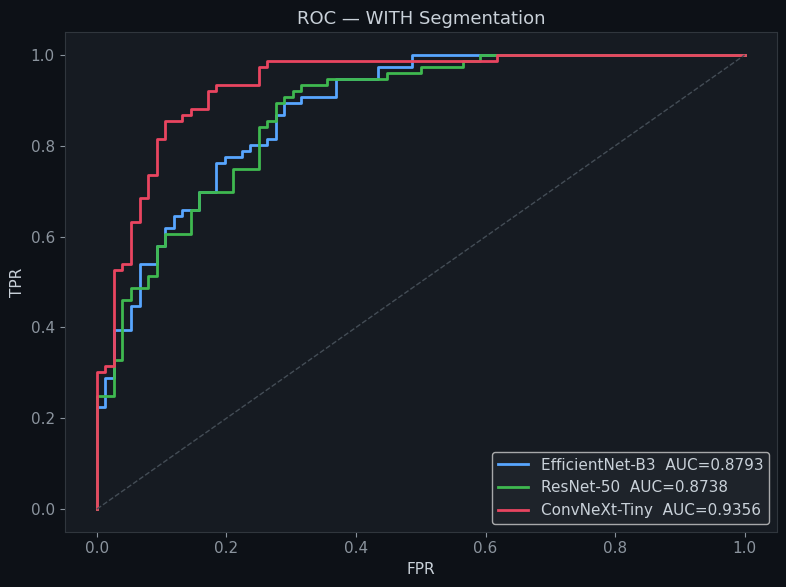

Saved -> outputs/visualizations/cls_withseg_roc.png


In [12]:
print(f'\n{"="*62}')
print(f'  CLASSIFICATION WITH SEGMENTATION — TEST RESULTS')
print(f'{"="*62}')
print(f'  {"Model":<20} {"Acc%":>8} {"F1":>8} {"AUC":>8}')
print(f'{"-"*50}')
for name, r in all_results.items():
    print(f'  {name:<20} {r["acc"]*100:>8.2f} {r["f1"]:>8.4f} {r["auc"]:>8.4f}')
print(f'{"="*62}')
best = max(all_results, key=lambda k: all_results[k]['f1'])
print(f'  Best model: {best}  (F1={all_results[best]["f1"]:.4f})')

# ROC curves
fig, ax = plt.subplots(figsize=(8, 6), facecolor='#0d1117')
ax.set_facecolor('#161b22')
for (name, r), col in zip(all_results.items(), [BLUE, GREEN, ACCENT]):
    ax.plot(r['fpr'], r['tpr'], color=col, linewidth=2, label=f"{name}  AUC={r['auc']:.4f}")
ax.plot([0,1],[0,1], color='#444d56', linewidth=1, linestyle='--')
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('ROC — WITH Segmentation', color='#c9d1d9', fontsize=13)
ax.legend(facecolor='#21262d', labelcolor='#c9d1d9')
ax.spines[:].set_edgecolor('#30363d')
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, 'cls_withseg_roc.png'), dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('Saved -> outputs/visualizations/cls_withseg_roc.png')